In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, MaxPooling1D

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
df = pd.read_csv('crypto_combine.csv')

In [4]:
df.head()

,Crypto,Date,Open,High,Low,Close
0,BTC,12/31/19,7254.0,7309.0,7132.0,7171.0
1,BTC,12/30/19,7402.0,7430.0,7217.0,7254.0
2,BTC,12/29/19,7334.0,7529.0,7295.0,7402.0
3,BTC,12/28/19,7235.0,7359.0,7235.0,7334.0
4,BTC,12/27/19,7208.0,7267.0,7087.0,7235.0


In [5]:
df.tail()

,Crypto,Date,Open,High,Low,Close
7894,XRP,1/5/19,0.36,0.36,0.35,0.36
7895,XRP,1/4/19,0.36,0.36,0.35,0.36
7896,XRP,1/3/19,0.37,0.38,0.35,0.36
7897,XRP,1/2/19,0.36,0.37,0.36,0.37
7898,XRP,1/1/19,0.35,0.36,0.34,0.36


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crypto  7899 non-null   object 
 1   Date    7899 non-null   object 
 2   Open    7899 non-null   float64
 3   High    7899 non-null   float64
 4   Low     7899 non-null   float64
 5   Close   7899 non-null   float64
dtypes: float64(4), object(2)
memory usage: 370.4+ KB


In [7]:
# Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Returns'] = df.groupby('Crypto')['Close'].pct_change()

# Encoding
le = LabelEncoder()
df['Crypto_Enc'] = le.fit_transform(df['Crypto'])

# Features and Target
features = ['Open', 'High', 'Low', 'Crypto_Enc', 'Year', 'Month']
X = df[features].fillna(0)
y = df['Close']

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

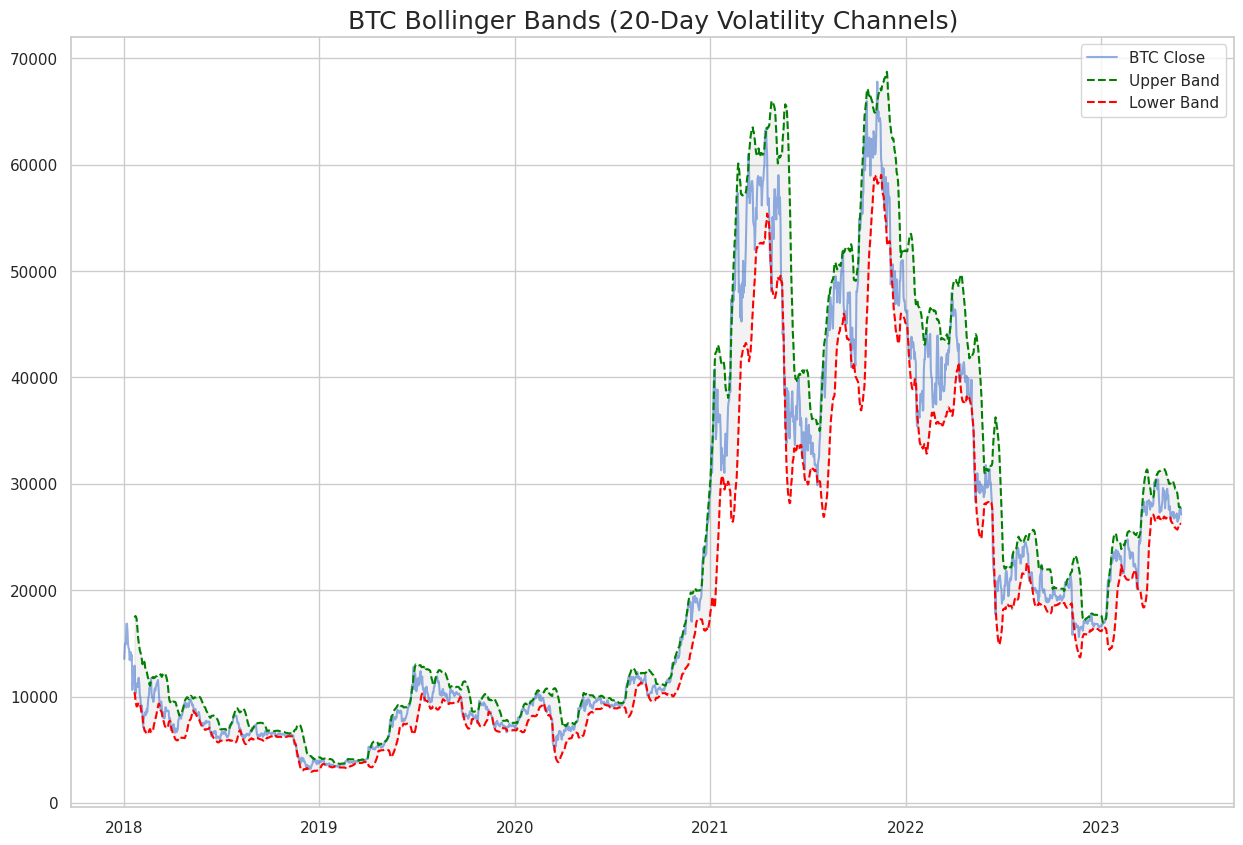

In [8]:
plt.figure(figsize=(15, 10))
btc = df[df['Crypto'] == 'BTC'].copy()
btc['MA20'] = btc['Close'].rolling(window=20).mean()
btc['STD20'] = btc['Close'].rolling(window=20).std()
btc['Upper'] = btc['MA20'] + (btc['STD20'] * 2)
btc['Lower'] = btc['MA20'] - (btc['STD20'] * 2)
plt.plot(btc['Date'], btc['Close'], label='BTC Close', alpha=0.6)
plt.plot(btc['Date'], btc['Upper'], label='Upper Band', linestyle='--', color='green')
plt.plot(btc['Date'], btc['Lower'], label='Lower Band', linestyle='--', color='red')
plt.fill_between(btc['Date'], btc['Lower'], btc['Upper'], color='gray', alpha=0.1)
plt.title('BTC Bollinger Bands (20-Day Volatility Channels)', fontsize=18)
plt.legend()
plt.show()

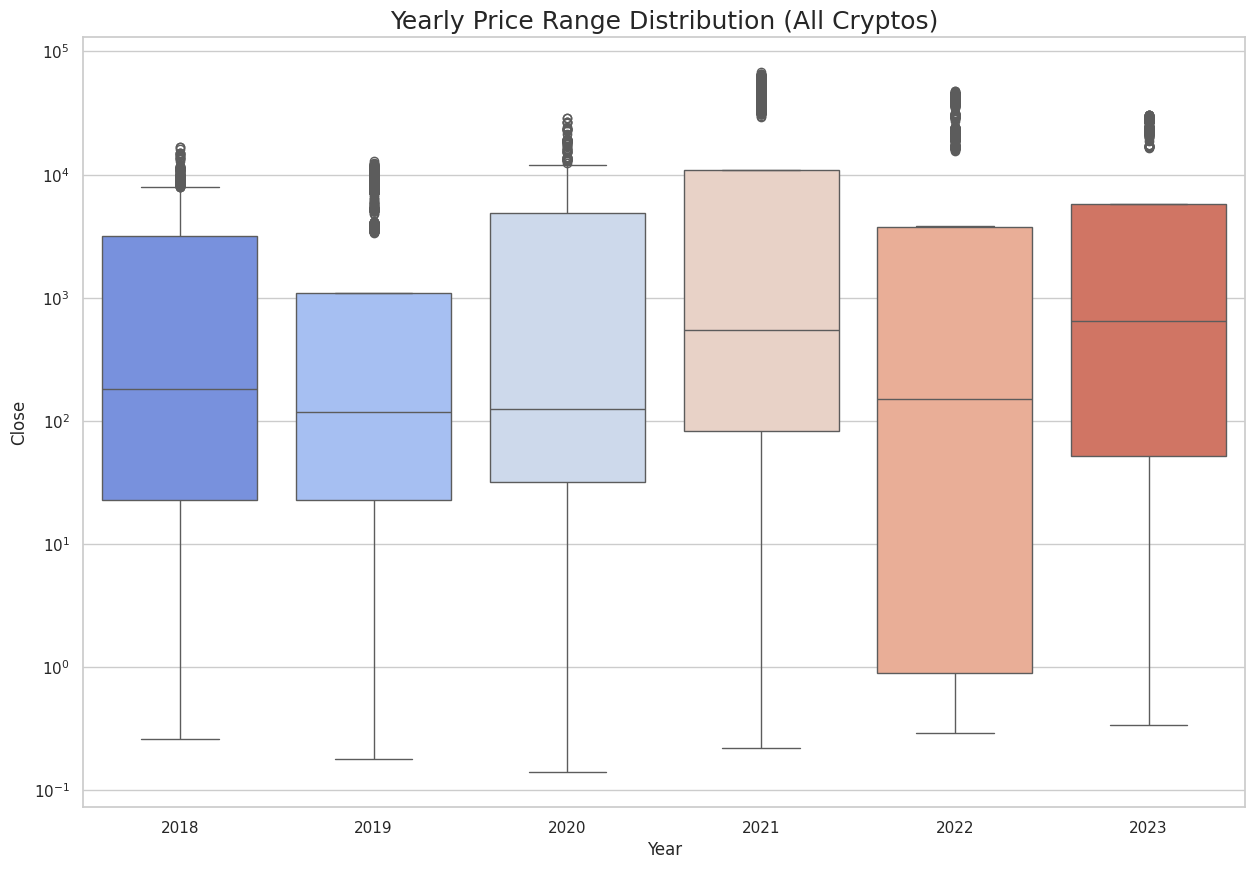

In [9]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='Year', y='Close', data=df, palette='coolwarm')
plt.title('Yearly Price Range Distribution (All Cryptos)', fontsize=18)
plt.yscale('log')
plt.show()

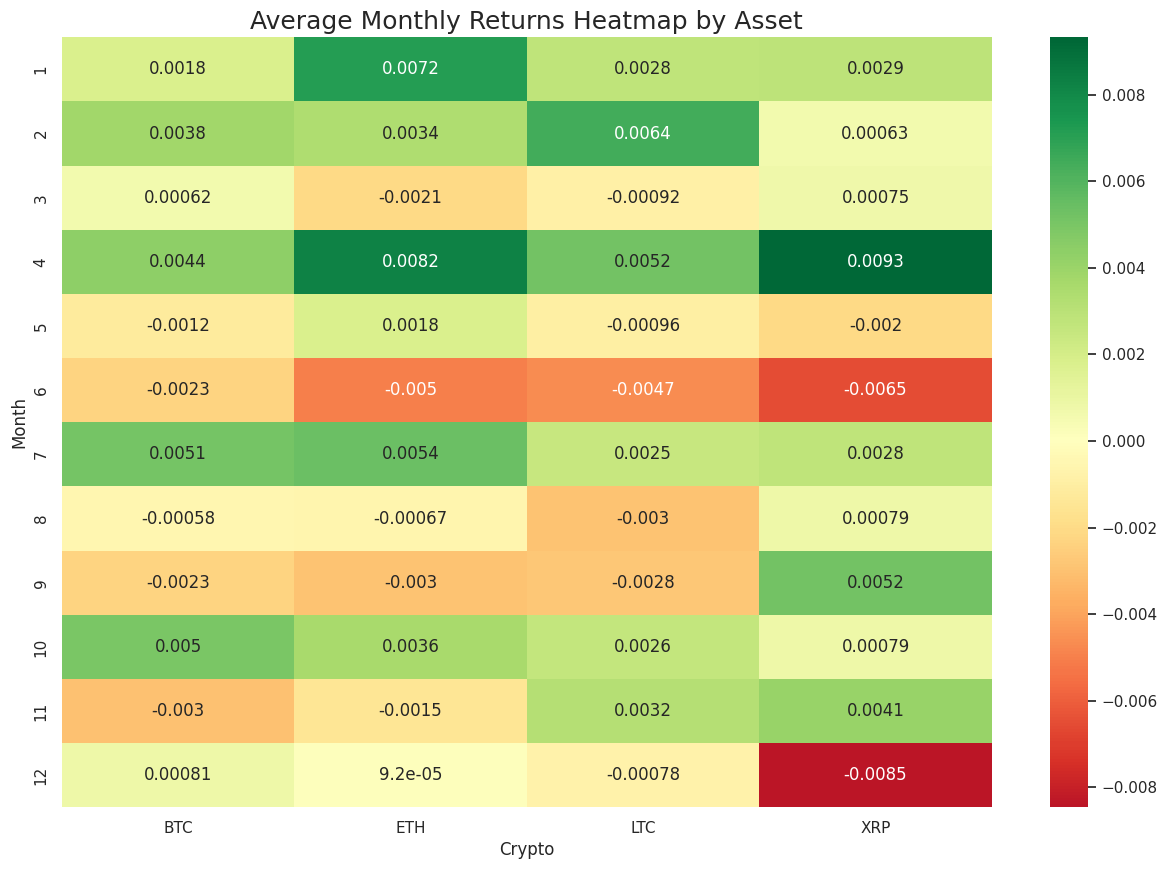

In [10]:
plt.figure(figsize=(15, 10))
monthly_ret = df.pivot_table(index='Month', columns='Crypto', values='Returns', aggfunc='mean')
sns.heatmap(monthly_ret, annot=True, cmap='RdYlGn', center=0)
plt.title('Average Monthly Returns Heatmap by Asset', fontsize=18)
plt.show()

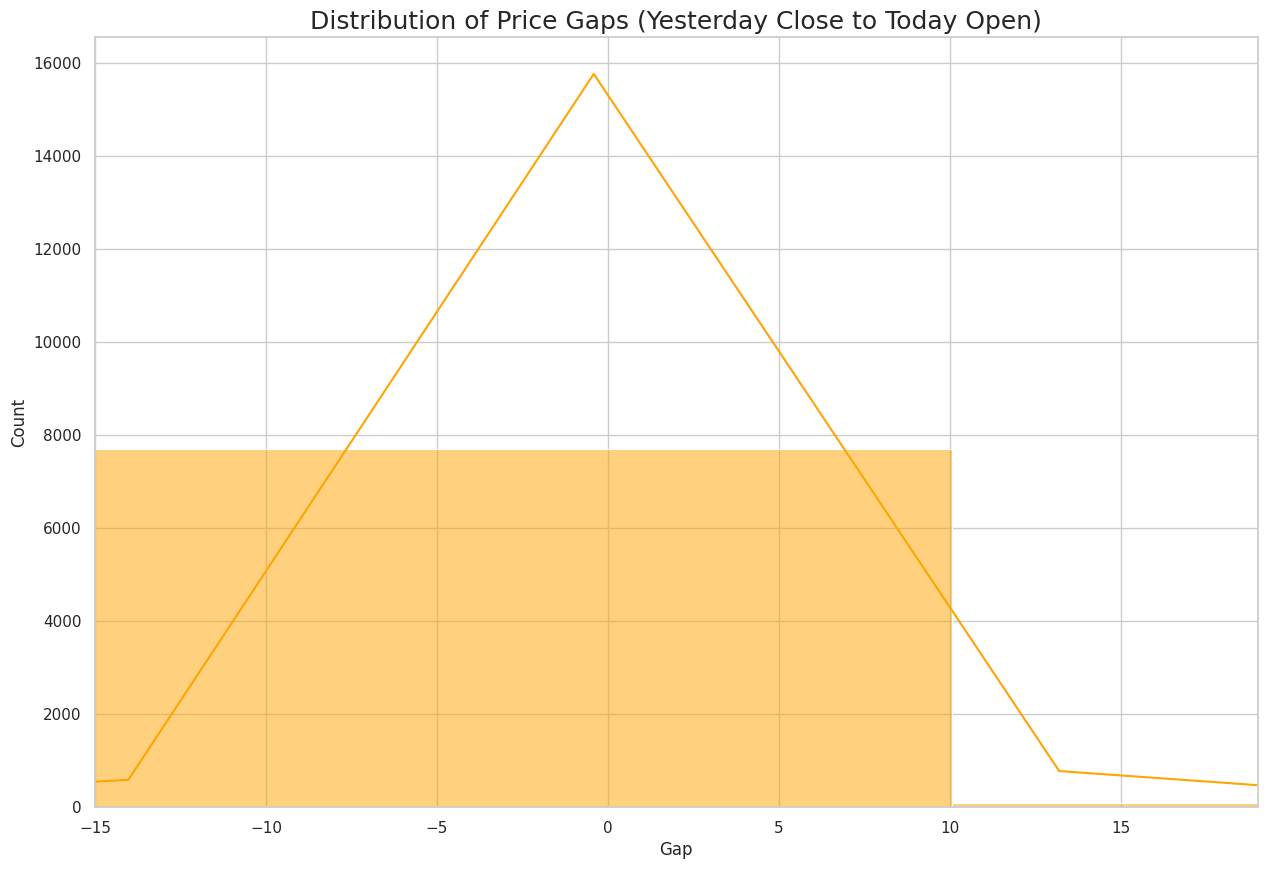

In [11]:
plt.figure(figsize=(15, 10))
df['Gap'] = df.groupby('Crypto')['Open'].shift(0) - df.groupby('Crypto')['Close'].shift(1)
sns.histplot(df['Gap'].dropna(), bins=100, color='orange', kde=True)
plt.title('Distribution of Price Gaps (Yesterday Close to Today Open)', fontsize=18)
plt.xlim(df['Gap'].quantile(0.01), df['Gap'].quantile(0.99))
plt.show()

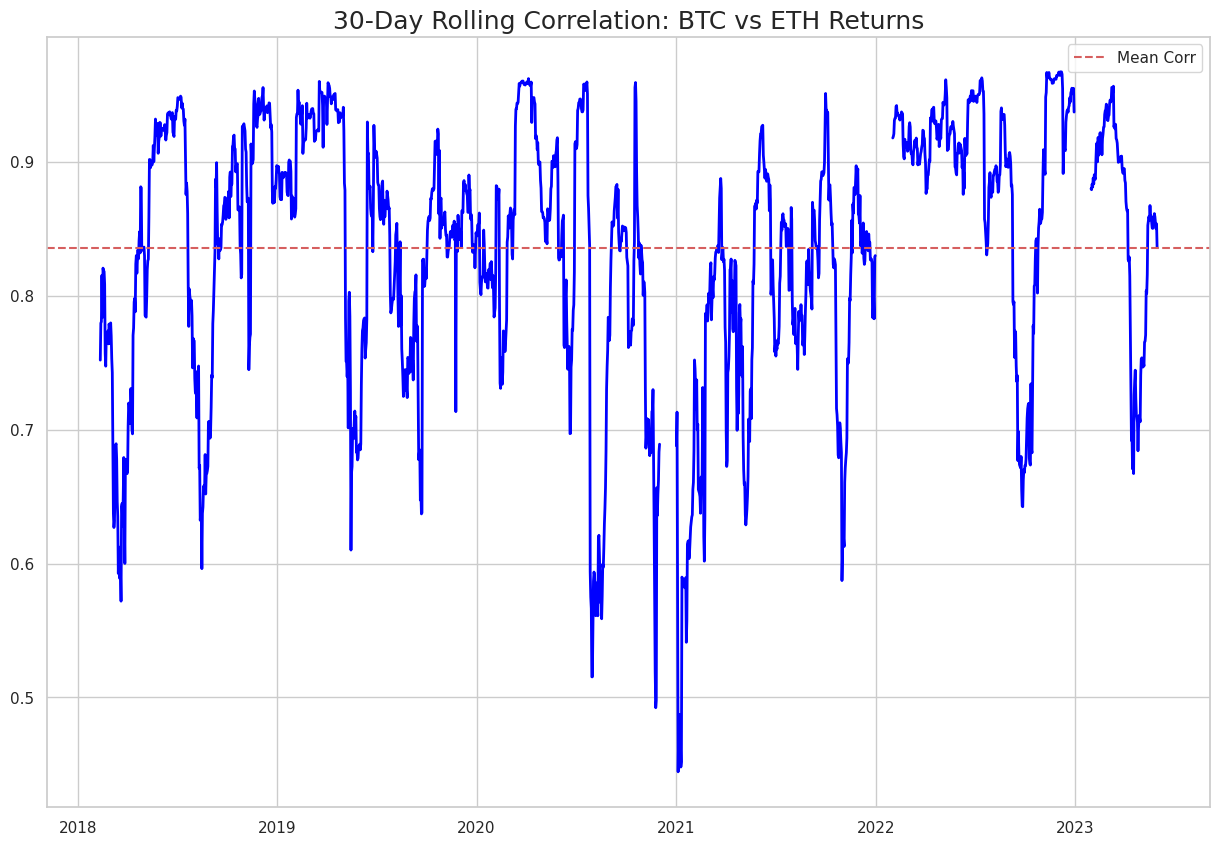

In [12]:
plt.figure(figsize=(15, 10))
btc_ret = df[df['Crypto']=='BTC'].set_index('Date')['Returns']
eth_ret = df[df['Crypto']=='ETH'].set_index('Date')['Returns']
rolling_corr = btc_ret.rolling(window=30).corr(eth_ret)
plt.plot(rolling_corr, color='blue', linewidth=2)
plt.title('30-Day Rolling Correlation: BTC vs ETH Returns', fontsize=18)
plt.axhline(y=rolling_corr.mean(), color='r', linestyle='--', label='Mean Corr')
plt.legend()
plt.show()

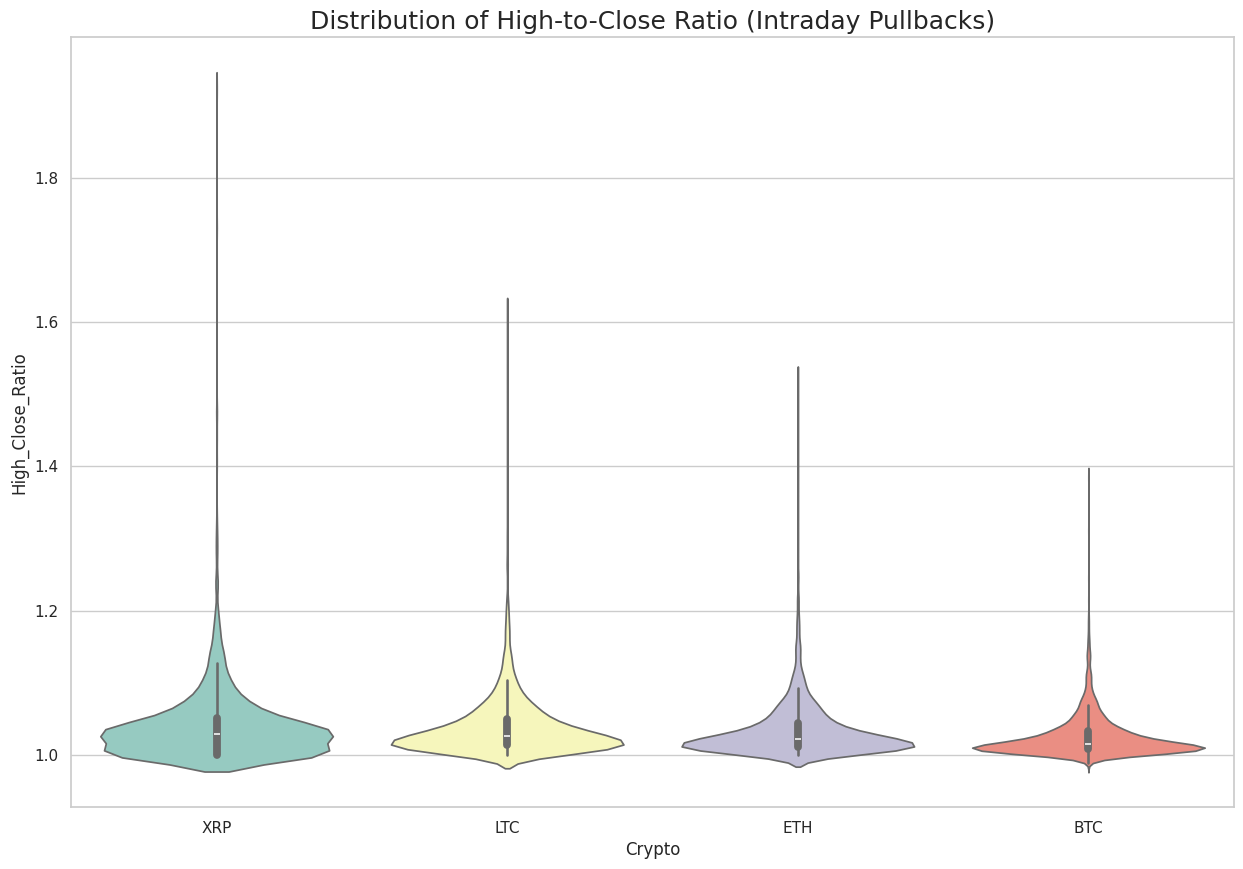

In [13]:
plt.figure(figsize=(15, 10))
df['High_Close_Ratio'] = df['High'] / df['Close']
sns.violinplot(x='Crypto', y='High_Close_Ratio', data=df, palette='Set3')
plt.title('Distribution of High-to-Close Ratio (Intraday Pullbacks)', fontsize=18)
plt.show()

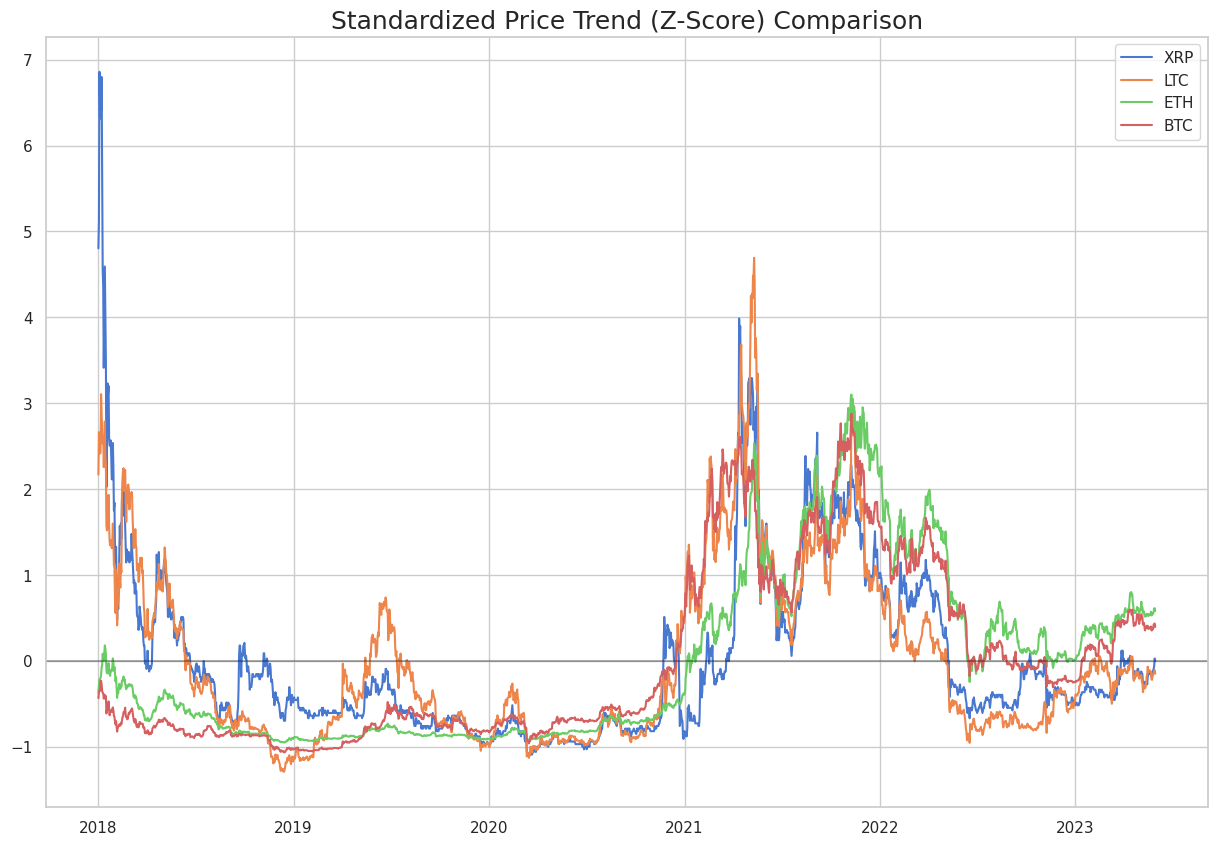

In [14]:
plt.figure(figsize=(15, 10))
for crypto in df['Crypto'].unique():
    subset = df[df['Crypto'] == crypto].copy()
    subset['Z_Price'] = (subset['Close'] - subset['Close'].mean()) / subset['Close'].std()
    plt.plot(subset['Date'], subset['Z_Price'], label=crypto)
plt.title('Standardized Price Trend (Z-Score) Comparison', fontsize=18)
plt.axhline(0, color='black', alpha=0.3)
plt.legend()
plt.show()

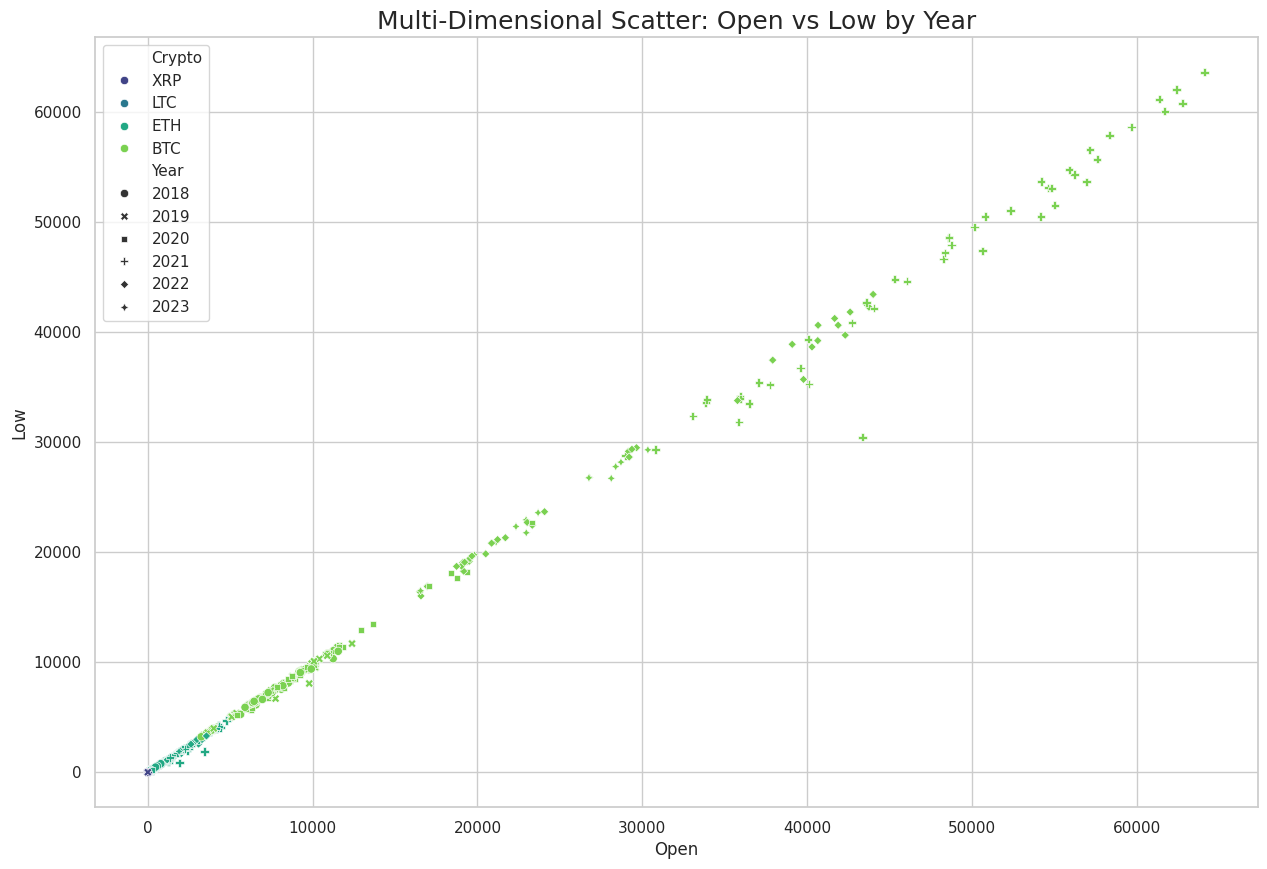

In [15]:
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df.sample(1000), x='Open', y='Low', hue='Crypto', style='Year', palette='viridis')
plt.title('Multi-Dimensional Scatter: Open vs Low by Year', fontsize=18)
plt.show()

In [16]:
# ==========================================
# 3. MODELS: 2 ML AND 1 DL
# ==========================================

# --- ML Model 1: K-Neighbors Regressor ---
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

# --- ML Model 2: Bayesian Ridge Regression ---
br_model = BayesianRidge()
br_model.fit(X_train, y_train.ravel())
br_preds = br_model.predict(X_test)

# --- DL Model: 1D CNN (Convolutional Neural Network) ---
# Reshape for CNN: (samples, time_steps, features)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_cnn, y_train, epochs=20, batch_size=32, verbose=0)
cnn_preds = cnn_model.predict(X_test_cnn)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [17]:
# ==========================================
# 4. EVALUATION & RANKING
# ==========================================

def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = [
    get_metrics(y_test, knn_preds, 'K-Nearest Neighbors'),
    get_metrics(y_test, br_preds, 'Bayesian Ridge'),
    get_metrics(y_test, cnn_preds, '1D CNN (Deep Learning)')
]

# Ranking Table
rank_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = 'Rank'

print("\n" + "="*40)
print("FINAL MODEL RANKING")
print("="*40)
print(rank_df)


FINAL MODEL RANKING
                       Model  R2 Score       MAE      RMSE
Rank                                                      
1             Bayesian Ridge  0.999568  0.001045  0.003729
2        K-Nearest Neighbors  0.998778  0.001909  0.006268
3     1D CNN (Deep Learning)  0.997346  0.005731  0.009237


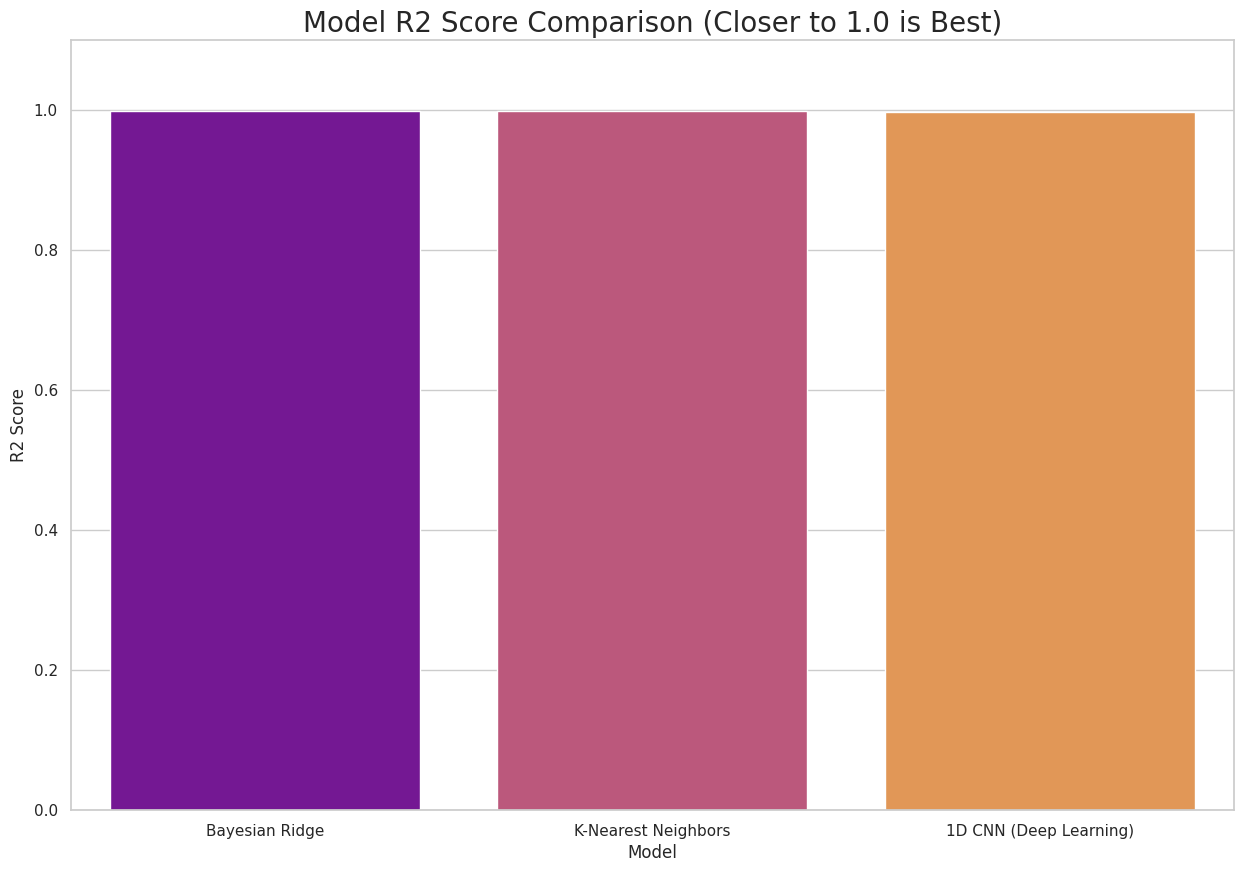

In [18]:
# Final Performance Chart
plt.figure(figsize=(15, 10))
sns.barplot(x='Model', y='R2 Score', data=rank_df, palette='plasma')
plt.title('Model R2 Score Comparison (Closer to 1.0 is Best)', fontsize=20)
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
plt.show()